# 01 — Merge XGBoost PD Scores with Original LendingClub Fields

**Author:** Shuxin Dong  
**Project:** Math 586 — Loan Approval Optimization  
**Purpose of this notebook:** Build the master input file for the optimization stage.


## 1. Imports and project paths

Set up libraries and define every file path in one place. If a path ever needs to
change, this is the only cell that has to change.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# This notebook lives in notebooks/, so the project root is one level up
PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

# Input files (already on disk)
SCORES_PATH = RAW_DIR / "xgboost_test_2017_scores.csv"
ACCEPTED_PATH = RAW_DIR / "accepted_2007_to_2018Q4.csv"

# Output we will produce
ENRICHED_OUTPUT_PATH = PROCESSED_DIR / "loans_enriched.csv"

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print(f"Project root:  {PROJECT_ROOT}")
print(f"Scores file:   {SCORES_PATH}  (exists: {SCORES_PATH.exists()})")
print(f"Accepted file: {ACCEPTED_PATH}  (exists: {ACCEPTED_PATH.exists()})")

Project root:  /Users/dongshuxin/Desktop/Banking Project
Scores file:   /Users/dongshuxin/Desktop/Banking Project/data/raw/xgboost_test_2017_scores.csv  (exists: True)
Accepted file: /Users/dongshuxin/Desktop/Banking Project/data/raw/accepted_2007_to_2018Q4.csv  (exists: True)


## 2. Load the XGBoost scores file

This file is small (~19 MB, 169k rows) and fits in memory comfortably.  
We confirm the schema and that `id` is an integer column — that's what we will merge on later.

In [2]:
scores = pd.read_csv(SCORES_PATH)

print(f"Shape: {scores.shape}")
print(f"\nColumns: {scores.columns.tolist()}")
print(f"\nDtypes:")
print(scores.dtypes)
print(f"\nFirst 3 rows:")
scores.head(3)

Shape: (169321, 14)

Columns: ['id', 'issue_year', 'loan_status', 'target_default', 'pred_default_prob', 'loan_amnt', 'term', 'purpose', 'addr_state', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high', 'application_type']

Dtypes:
id                     int64
issue_year             int64
loan_status              str
target_default         int64
pred_default_prob    float64
loan_amnt            float64
term                     str
purpose                  str
addr_state               str
annual_inc           float64
dti                  float64
fico_range_low       float64
fico_range_high      float64
application_type         str
dtype: object

First 3 rows:


,id,issue_year,loan_status,target_default,pred_default_prob,loan_amnt,term,purpose,addr_state,annual_inc,dti,fico_range_low,fico_range_high,application_type
0,120113784,2017,Fully Paid,0,0.766557,35000.0,60 months,house,NY,85000.0,12.14,680.0,684.0,Individual
1,120037097,2017,Fully Paid,0,0.676576,10000.0,36 months,debt_consolidation,KY,10000.0,49.94,705.0,709.0,Joint App
2,120122709,2017,Fully Paid,0,0.666939,10000.0,60 months,debt_consolidation,NJ,58000.0,21.64,675.0,679.0,Individual


## 3. Build the set of loan IDs we need

We collect the 169k unique loan IDs from the scores file into a Python `set`.
In Cell 4 we use this set to filter the large accepted CSV chunk-by-chunk —
we only keep rows that we actually care about, which keeps memory usage low.

In [7]:
# Build the set of loan IDs we need
# Convert to strings to match accepted CSV format (which has polluted rows forcing str dtype)

target_ids = set(scores["id"].astype(str).unique())

print(f"Number of unique loan IDs to fetch: {len(target_ids):,}")
print(f"Sample IDs: {list(target_ids)[:5]}")
print(f"Type: {type(list(target_ids)[0])}")

Number of unique loan IDs to fetch: 169,321
Sample IDs: ['120048349', '104180777', '96424166', '94411057', '112047845']
Type: <class 'str'>


## 4. Chunked read of the accepted CSV

The original `accepted_2007_to_2018Q4.csv` is ~1.6 GB and ~2.26 million rows —
loading it fully on an 8 GB machine would be risky. Instead we:

- Restrict to the 9 columns we actually need.
- Read in chunks of 100k rows.
- Keep only rows whose `id` is in our target set.
- Concatenate the kept chunks at the end.

**Expected runtime:** about 1–2 minutes. The terminal/output area should show
incremental progress.

In [8]:
#  Chunked read of accepted CSV
# - Force id column as string to handle polluted rows
# - Skip rows where id isn't a clean numeric string

needed_cols = [
    "id",
    "loan_amnt",
    "int_rate",
    "installment",
    "term",
    "grade",
    "sub_grade",
    "issue_d",
    "loan_status",
]

print(f"Reading {ACCEPTED_PATH.name} in chunks...")
print(f"Looking for {len(target_ids):,} matching loan IDs.\n")

chunks = []
chunks_read = 0
rows_kept = 0
chunk_size = 100_000

reader = pd.read_csv(
    ACCEPTED_PATH,
    usecols=needed_cols,
    chunksize=chunk_size,
    low_memory=False,
    dtype={"id": str},  # ← force str to handle polluted rows
)

for chunk in reader:
    chunks_read += 1
    # Drop rows where id isn't numeric (footer/junk rows in the raw CSV)
    chunk = chunk[chunk["id"].str.match(r"^\d+$", na=False)]
    if chunk.empty:
        continue
    matched = chunk[chunk["id"].isin(target_ids)]
    if len(matched) > 0:
        chunks.append(matched)
        rows_kept += len(matched)
    if chunks_read % 5 == 0:
        print(f"  Read {chunks_read} chunks ({chunks_read * chunk_size:,} rows scanned), kept {rows_kept:,} so far")

print(f"\nFinished. Read {chunks_read} chunks total.")
print(f"Kept {rows_kept:,} matching rows.")

accepted_subset = pd.concat(chunks, ignore_index=True)

# Now safely convert id back to int64 (we've filtered out junk)
accepted_subset["id"] = accepted_subset["id"].astype("int64")

print(f"\nFinal accepted_subset shape: {accepted_subset.shape}")
accepted_subset.head(3)

Reading accepted_2007_to_2018Q4.csv in chunks...
Looking for 169,321 matching loan IDs.

  Read 5 chunks (500,000 rows scanned), kept 0 so far
  Read 10 chunks (1,000,000 rows scanned), kept 88,346 so far
  Read 15 chunks (1,500,000 rows scanned), kept 88,346 so far
  Read 20 chunks (2,000,000 rows scanned), kept 135,220 so far

Finished. Read 23 chunks total.
Kept 169,321 matching rows.

Final accepted_subset shape: (169321, 9)


,id,loan_amnt,term,int_rate,installment,grade,sub_grade,issue_d,loan_status
0,120113784,35000.0,60 months,12.62,789.57,C,C1,Sep-2017,Fully Paid
1,120037097,10000.0,36 months,15.05,346.90,C,C4,Sep-2017,Fully Paid
2,120122709,10000.0,60 months,13.59,230.57,C,C2,Sep-2017,Fully Paid


## 5. Clean the `int_rate` and `term` columns



In [9]:
print("Before cleaning:")
print(f"  int_rate sample: {accepted_subset['int_rate'].iloc[:3].tolist()}")
print(f"  term sample:     {accepted_subset['term'].iloc[:3].tolist()}")

# int_rate: strip % and convert to float (annual rate as a percentage)
accepted_subset["int_rate"] = (
    accepted_subset["int_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
    .astype(float)
)

# term: extract the integer (36 or 60) into term_months
accepted_subset["term_months"] = (
    accepted_subset["term"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

print("\nAfter cleaning:")
print(f"  int_rate sample:    {accepted_subset['int_rate'].iloc[:3].tolist()}")
print(f"  int_rate range:     {accepted_subset['int_rate'].min():.2f} to {accepted_subset['int_rate'].max():.2f}")
print(f"  term_months sample: {accepted_subset['term_months'].iloc[:3].tolist()}")
print(f"  term_months unique: {sorted(accepted_subset['term_months'].unique())}")

Before cleaning:
  int_rate sample: [12.62, 15.05, 13.59]
  term sample:     [' 60 months', ' 36 months', ' 60 months']

After cleaning:
  int_rate sample:    [12.62, 15.05, 13.59]
  int_rate range:     5.32 to 30.99
  term_months sample: [60, 36, 60]
  term_months unique: [np.int64(36), np.int64(60)]


## 6. Merge the two datasets

Left-join the scores file with the accepted subset on `id`. Because the scores
file is the "source of truth" for which loans we are working with, every row in
`scores` should find a match. We drop the columns that already exist on the left
side (`loan_amnt`, `term`, `loan_status`) to avoid `_x` / `_y` duplicates.

In [10]:
accepted_to_merge = accepted_subset.drop(columns=["loan_amnt", "term", "loan_status"])

enriched = scores.merge(accepted_to_merge, on="id", how="left")

print(f"scores shape:           {scores.shape}")
print(f"accepted_subset shape:  {accepted_subset.shape}")
print(f"enriched shape:         {enriched.shape}")
print(f"\nColumns now: {enriched.columns.tolist()}")

# Sanity: how many rows failed to merge?
n_missing_int_rate = enriched["int_rate"].isna().sum()
print(f"\nRows missing int_rate after merge: {n_missing_int_rate}")
print(f"  (should be 0 or very small)")

scores shape:           (169321, 14)
accepted_subset shape:  (169321, 10)
enriched shape:         (169321, 20)

Columns now: ['id', 'issue_year', 'loan_status', 'target_default', 'pred_default_prob', 'loan_amnt', 'term', 'purpose', 'addr_state', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high', 'application_type', 'int_rate', 'installment', 'grade', 'sub_grade', 'issue_d', 'term_months']

Rows missing int_rate after merge: 0
  (should be 0 or very small)


## 7. Sanity check — `int_rate`, predicted PD, and actual default




In [11]:
corr_pred = enriched["int_rate"].corr(enriched["pred_default_prob"])
corr_actual = enriched["int_rate"].corr(enriched["target_default"])

print(f"Corr(int_rate, predicted PD):  {corr_pred:.4f}")
print(f"  (expected: positive, around 0.4 to 0.7)")
print(f"Corr(int_rate, actual default): {corr_actual:.4f}")

print(f"\nMean predicted PD:    {enriched['pred_default_prob'].mean():.4f}")
print(f"Mean actual default:  {enriched['target_default'].mean():.4f}")
print(f"  (gap reveals miscalibration; we will fix this in the next notebook)")

Corr(int_rate, predicted PD):  0.6265
  (expected: positive, around 0.4 to 0.7)
Corr(int_rate, actual default): 0.2602

Mean predicted PD:    0.4587
Mean actual default:  0.2313
  (gap reveals miscalibration; we will fix this in the next notebook)


By grade:
grade  mean_int_rate  mean_pd  actual_default     n
    A       6.993924 0.247396        0.068836 26890
    B      10.595983 0.397101        0.157273 47001
    C      14.272237 0.510859        0.262332 54919
    D      18.760796 0.563590        0.346927 24521
    E      24.710390 0.623617        0.411298 10214
    F      29.775917 0.700769        0.474102  3649
    G      30.882078 0.729809        0.508228  2127


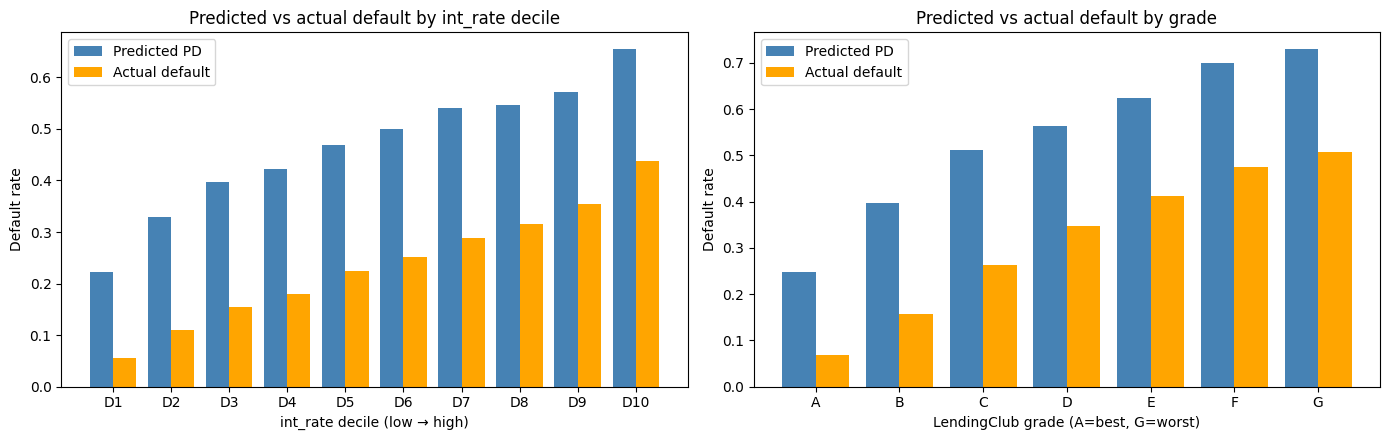

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: by int_rate decile
enriched["int_rate_bin"] = pd.qcut(enriched["int_rate"], q=10, duplicates="drop")
bin_stats = (
    enriched.groupby("int_rate_bin", observed=True)
    .agg(mean_pd=("pred_default_prob", "mean"),
         actual_default=("target_default", "mean"),
         n=("id", "count"))
    .reset_index()
)
x = np.arange(len(bin_stats))
axes[0].bar(x - 0.2, bin_stats["mean_pd"], width=0.4, label="Predicted PD", color="steelblue")
axes[0].bar(x + 0.2, bin_stats["actual_default"], width=0.4, label="Actual default", color="orange")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"D{i+1}" for i in range(len(bin_stats))])
axes[0].set_xlabel("int_rate decile (low → high)")
axes[0].set_ylabel("Default rate")
axes[0].set_title("Predicted vs actual default by int_rate decile")
axes[0].legend()

# Right: by LendingClub grade
if enriched["grade"].notna().sum() > 100:
    grade_stats = (
        enriched.groupby("grade", observed=True)
        .agg(mean_int_rate=("int_rate", "mean"),
             mean_pd=("pred_default_prob", "mean"),
             actual_default=("target_default", "mean"),
             n=("id", "count"))
        .reset_index()
        .sort_values("grade")
    )
    print("By grade:")
    print(grade_stats.to_string(index=False))

    xg = np.arange(len(grade_stats))
    axes[1].bar(xg - 0.2, grade_stats["mean_pd"], width=0.4, label="Predicted PD", color="steelblue")
    axes[1].bar(xg + 0.2, grade_stats["actual_default"], width=0.4, label="Actual default", color="orange")
    axes[1].set_xticks(xg)
    axes[1].set_xticklabels(grade_stats["grade"])
    axes[1].set_xlabel("LendingClub grade (A=best, G=worst)")
    axes[1].set_ylabel("Default rate")
    axes[1].set_title("Predicted vs actual default by grade")
    axes[1].legend()

plt.tight_layout()
plt.show()

Loan count by grade:
grade     n       pct
    A 26890 15.881078
    B 47001 27.758518
    C 54919 32.434843
    D 24521 14.481960
    E 10214  6.032329
    F  3649  2.155078
    G  2127  1.256194

Total loans:           169,321
A + B + C combined:    128,810  (76.1%)
F + G combined:        5,776    (3.4%)

Insight: the platform is dominated by mid-credit borrowers.
High-risk loans (F/G) are a small minority.


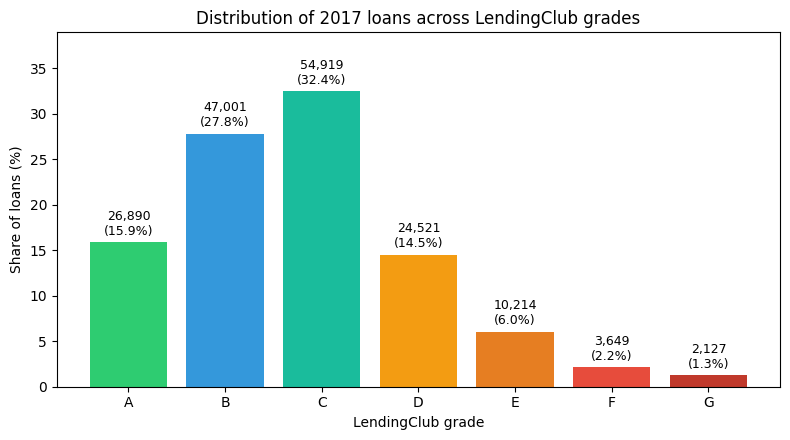

In [14]:
# Distribution of loans across LendingClub grades
# Story: the platform is dominated by mid-credit borrowers (A/B/C),
# with very few high-risk (F/G) loans

grade_dist = (
    enriched.groupby("grade", observed=True)
    .size()
    .reset_index(name="n")
    .sort_values("grade")
)
grade_dist["pct"] = grade_dist["n"] / grade_dist["n"].sum() * 100

# Print summary
total = grade_dist["n"].sum()
abc = grade_dist[grade_dist["grade"].isin(["A", "B", "C"])]["n"].sum()
fg = grade_dist[grade_dist["grade"].isin(["F", "G"])]["n"].sum()

print("Loan count by grade:")
print(grade_dist.to_string(index=False))
print(f"\nTotal loans:           {total:,}")
print(f"A + B + C combined:    {abc:,}  ({abc/total*100:.1f}%)")
print(f"F + G combined:        {fg:,}    ({fg/total*100:.1f}%)")
print(f"\nInsight: the platform is dominated by mid-credit borrowers.")
print(f"High-risk loans (F/G) are a small minority.")

# Visualize as a single bar chart with percentages
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#2ecc71", "#3498db", "#1abc9c", "#f39c12", "#e67e22", "#e74c3c", "#c0392b"]
bars = ax.bar(grade_dist["grade"], grade_dist["pct"], color=colors[: len(grade_dist)])

# Annotate each bar with count and percentage
for bar, n, pct in zip(bars, grade_dist["n"], grade_dist["pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{n:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xlabel("LendingClub grade")
ax.set_ylabel("Share of loans (%)")
ax.set_title("Distribution of 2017 loans across LendingClub grades")
ax.set_ylim(0, max(grade_dist["pct"]) * 1.2)
plt.tight_layout()
plt.show()

## 8. Save the enriched dataset

Drop the temporary binning column and write the result to
`data/processed/loans_enriched.csv`. This file is the input for the next
notebook (`02_expected_profit.ipynb`), which calibrates the PD and computes
the expected profit per loan.

In [13]:
if "int_rate_bin" in enriched.columns:
    enriched = enriched.drop(columns=["int_rate_bin"])

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
enriched.to_csv(ENRICHED_OUTPUT_PATH, index=False)

print(f"Saved enriched dataset to: {ENRICHED_OUTPUT_PATH}")
print(f"Shape: {enriched.shape}")
print(f"File size: {ENRICHED_OUTPUT_PATH.stat().st_size / 1e6:.1f} MB")
print(f"\nFinal columns:")
for c in enriched.columns:
    print(f"  - {c}")

Saved enriched dataset to: /Users/dongshuxin/Desktop/Banking Project/data/processed/loans_enriched.csv
Shape: (169321, 20)
File size: 24.1 MB

Final columns:
  - id
  - issue_year
  - loan_status
  - target_default
  - pred_default_prob
  - loan_amnt
  - term
  - purpose
  - addr_state
  - annual_inc
  - dti
  - fico_range_low
  - fico_range_high
  - application_type
  - int_rate
  - installment
  - grade
  - sub_grade
  - issue_d
  - term_months
